# Diabetes Dataset — Data Inspection

## Healytics

This notebook performs the initial inspection of the Pima Indians Diabetes Dataset.

### Objectives
- Inspect dataset dimensions
- Inspect column names and data types
- Check missing values
- Check duplicate records
- Identify suspicious zero values
- Examine target distribution
- Generate basic descriptive statistics

> No preprocessing or data modification is performed in this notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load Dataset

In [4]:
df = pd.read_csv("../data/raw/diabetes.csv")

## Shape

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 9


## Columns

In [6]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## Data Types

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Missing values

In [8]:
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


## Duplicates

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Statistics

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## Zero value Analysis

In [11]:
zero_counts = (df == 0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


## Target Distribution

In [12]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


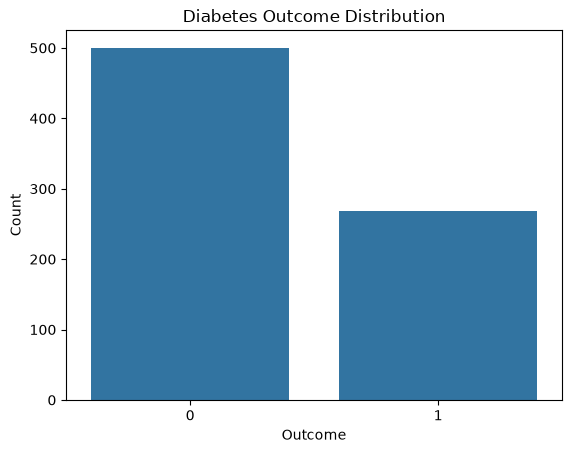

In [13]:
sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

### Initial Data Quality Findings

The raw Pima Indians Diabetes dataset contains 768 records and 9 columns.

Pandas reports no explicit missing values, but several medical measurements contain
zero values that are not physiologically meaningful and therefore represent
missing measurements.

The following columns contain zero-coded missing values:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

Zero is a valid value for Pregnancies and Outcome, so these columns will not be
treated as missing.

Missing-value handling will be performed during the preprocessing stage.
Imputation parameters will be learned only from the training data to prevent
data leakage.